# Exploratory Data Analysis

In [4]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
initial_inputs = np.load("initial_inputs.npy")
initial_outputs = np.load("initial_outputs.npy")
# summarize shape
print(initial_inputs.shape)
print(initial_outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(initial_inputs, columns=[f'input_{i}' for i in range(initial_inputs.shape[1])])
data['output'] = initial_outputs
print(data.head(20))

(40, 8)
(40,)
     input_0   input_1   input_2   input_3   input_4   input_5   input_6  \
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347   
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068   
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907   
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380   
9   0.984933  0.699506  0.998885  0.180148  0.580143  0.231087  0.490827   
10  0.112071  0.437736  0.596599  0.592776  0.226982  0.410105  0.921238   
11  0.791888  0.576191  0.694528  0.283424  0.136755  0.279162  0.842767  

## Observations


# Gaussian Process with EI, PI and UCB

Next sample UCB: [0.1959799 0.5       0.5       0.5       0.5       0.5       0.5
 0.5      ]
Next sample EI: [0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Next sample PI: [0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5]


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


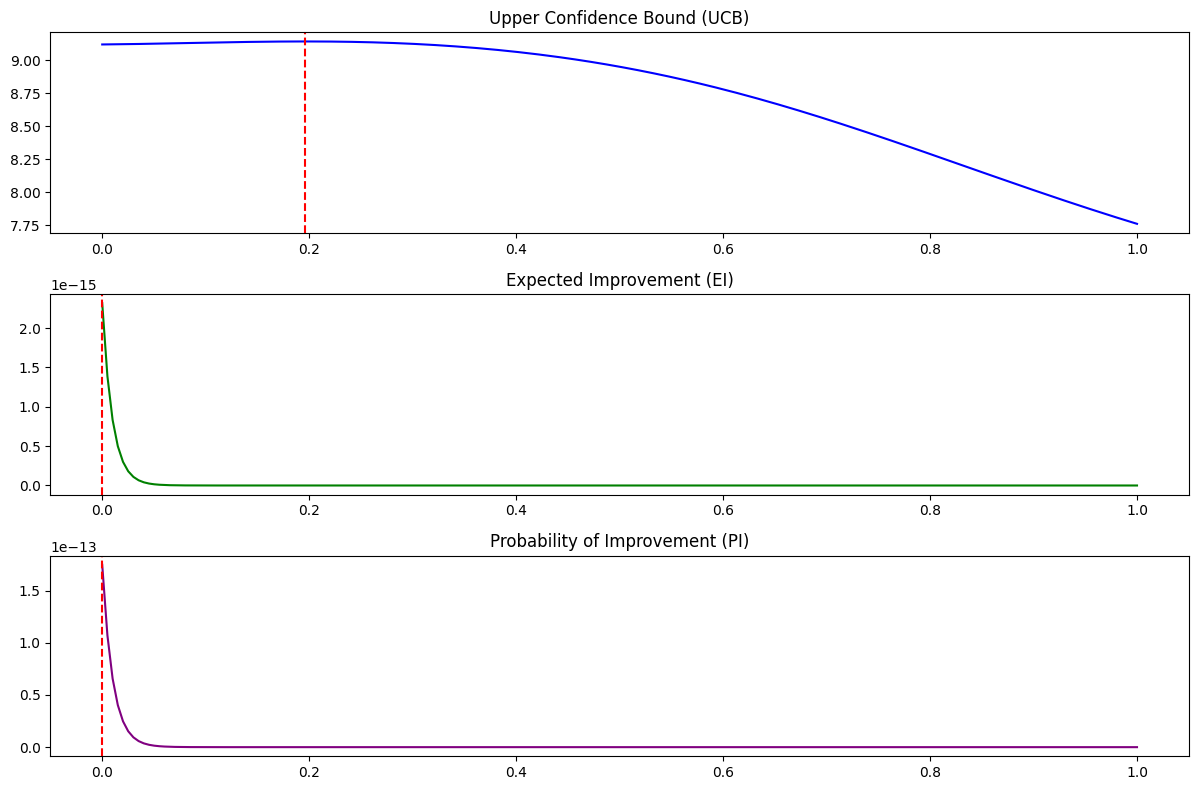

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

# Load the dataset
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Fit GP with Matern kernel
kernel = Matern(length_scale=np.ones(8), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Candidate points (vary first dimension)
n_candidates = 200
X_candidates = np.zeros((n_candidates, 8))
X_candidates[:, 0] = np.linspace(0, 1, n_candidates)
X_candidates[:, 1:] = 0.5

# Predictions
mu, sigma = gp.predict(X_candidates, return_std=True)
y_best = np.max(y)

# Acquisition functions
def UCB(mu, sigma, kappa=2.5): return mu + kappa * sigma
def EI(mu, sigma, y_best):
    improvement = mu - y_best
    Z = improvement / sigma
    return improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
def PI(mu, sigma, y_best):
    Z = (mu - y_best) / sigma
    return norm.cdf(Z)

ucb_values, ei_values, pi_values = UCB(mu, sigma), EI(mu, sigma, y_best), PI(mu, sigma, y_best)

# Next samples
next_ucb, next_ei, next_pi = X_candidates[np.argmax(ucb_values)], X_candidates[np.argmax(ei_values)], X_candidates[np.argmax(pi_values)]
print("Next sample UCB:", next_ucb)
print("Next sample EI:", next_ei)
print("Next sample PI:", next_pi)

# Visualisation
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(X_candidates[:, 0], ucb_values, 'b', label='UCB')
plt.axvline(next_ucb[0], color='r', linestyle='--')
plt.title('Upper Confidence Bound (UCB)')
plt.subplot(3, 1, 2)
plt.plot(X_candidates[:, 0], ei_values, 'g', label='EI')
plt.axvline(next_ei[0], color='r', linestyle='--')
plt.title('Expected Improvement (EI)')
plt.subplot(3, 1, 3)
plt.plot(X_candidates[:, 0], pi_values, 'purple', label='PI')
plt.axvline(next_pi[0], color='r', linestyle='--')
plt.title('Probability of Improvement (PI)')
plt.tight_layout()
plt.show()


## Observations
The choice for next sample is clearly nonsense.  With resort to random sample to start with, then improve my knowledge on how to get meaningful reults from these algorithms.

# Random Generation of next sample point

In [3]:
random_numbers = [np.random.random() for _ in range(8)]
print(random_numbers)

[0.3695108762344287, 0.3637354527597678, 0.19807354850799008, 0.8629644058690805, 0.35583667154815124, 0.5197758880675554, 0.2580107128712287, 0.6768046768685358]


# Week 1 Submission
0.369510-0.363735-0.198073-0.862964-0.355836-0.519775-0.258010-0.676804

# Xploring Other Surrogate Functions
## Student's T

/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/var/folders/dr/xw6m41dn1hdb8jp1_zyyh5g80000gn/T/ipykernel_45884/1447206102.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_next = float(black_box(x_next))
/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


EI final best value: 9.5985
UCB final best value: 9.5985
PI final best value: 9.5985


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/brucedies

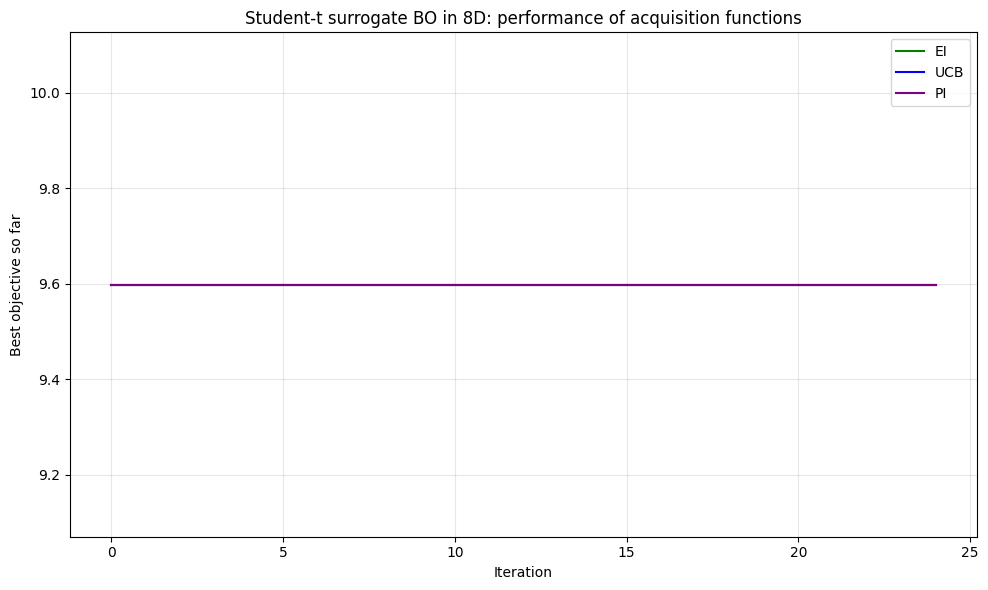

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from scipy.stats import qmc

np.random.seed(7)

# ----- Black-box objective (8D) -----
# Domain: [0, 1]^8; multimodal with mild heavy-tailed noise
def black_box(x):
    x = np.asarray(x)
    if x.ndim == 1:
        x = x[None, :]
    s1 = np.sin(6*np.pi*x[:,0]) + np.cos(6*np.pi*x[:,1])
    s2 = (x[:,2]-0.3)**2 + (x[:,3]-0.7)**2
    s3 = 0.6*np.sin(4*np.pi*(x[:,4]+x[:,5]))
    s4 = 0.8*np.exp(-5*((x[:,6]-0.2)**2 + (x[:,7]-0.8)**2))
    interaction = 0.4*np.sin(3*np.pi*x[:,0]*x[:,7])
    y = s1 - s2 + s3 + s4 + interaction
    # Heavy-tailed observation noise
    noise = student_t.rvs(df=5, size=y.shape) * 0.03
    return y + noise

# ----- Student-t surrogate using GP mean/std -----
class StudentTSurrogateBO:
    def __init__(self, dim=8, bounds=None, nu=5.0, kernel='matern', kappa=2.0):
        self.dim = dim
        self.bounds = np.array(bounds if bounds is not None else [[0.0,1.0]]*dim)
        self.nu = float(nu)
        self.kappa = float(kappa)
        if kernel == 'matern':
            k = Matern(length_scale=np.ones(dim), nu=2.5)
        elif kernel == 'rbf':
            k = RBF(length_scale=np.ones(dim))
        else:
            raise ValueError("kernel must be 'matern' or 'rbf'")
        self.gp = GaussianProcessRegressor(kernel=k, alpha=1e-6, normalize_y=True)
        self.X = None
        self.y = None

    def fit(self, X, y):
        self.X = np.asarray(X)
        self.y = np.asarray(y)
        self.gp.fit(self.X, self.y)

    def predict(self, X):
        mu, sigma = self.gp.predict(X, return_std=True)
        sigma = np.maximum(sigma, 1e-8)
        return mu, sigma

    # UCB (same form, but sigma is used as t-scale)
    def ucb(self, mu, sigma):
        return mu + self.kappa*sigma

    # PI under Student-t
    def pi(self, mu, sigma, y_best):
        z = (mu - y_best)/sigma
        return student_t.cdf(z, df=self.nu)

    # EI under Student-t via Monte Carlo
    def ei(self, mu, sigma, y_best, n_mc=512):
        n = mu.shape[0]
        t_samples = student_t.rvs(df=self.nu, size=(n_mc, n))
        f_samples = mu[None, :] + sigma[None, :]*t_samples
        improvements = np.maximum(0.0, f_samples - y_best)
        return improvements.mean(axis=0)

    def suggest(self, acq_name, candidates, y_best):
        mu, sigma = self.predict(candidates)
        if acq_name == 'ucb':
            acq = self.ucb(mu, sigma)
        elif acq_name == 'pi':
            acq = self.pi(mu, sigma, y_best)
        elif acq_name == 'ei':
            acq = self.ei(mu, sigma, y_best)
        else:
            raise ValueError("acq_name must be 'ucb', 'ei', or 'pi'")
        idx = np.argmax(acq)
        return candidates[idx], acq[idx]

# ----- BO loop -----
def run_bo(acq='ei', n_init=16, n_iter=24, nu=5.0, kernel='matern',
           kappa=2.0, n_candidates=4096, sobol=True):
    dim = 8
    bounds = np.array([[0.0,1.0]]*dim)
    # Initial design
    #if sobol:
    #    sampler = qmc.Sobol(d=dim, scramble=True)
    #    X_init = sampler.random(n_init)
    #else:
    #    X_init = np.random.rand(n_init, dim)
    #y_init = black_box(X_init)

    # load the data provided
    X_init = np.load("initial_inputs.npy")
    y_init = np.load("initial_outputs.npy")

    bo = StudentTSurrogateBO(dim=dim, bounds=bounds, nu=nu, kernel=kernel, kappa=kappa)
    bo.fit(X_init, y_init)

    # Candidate pool
    sampler_c = qmc.Sobol(d=dim, scramble=True)
    Xcand = sampler_c.random(n_candidates)

    X = [x for x in X_init]
    y = [float(v) for v in y_init]

    history_best = [np.max(y)]
    xs_best = [X[np.argmax(y)]]

    for t in range(n_iter):
        y_best = max(y)
        x_next, _ = bo.suggest(acq, Xcand, y_best)
        y_next = float(black_box(x_next))
        X.append(x_next); y.append(y_next)
        bo.fit(np.array(X), np.array(y))
        history_best.append(max(y))
        xs_best.append(X[np.argmax(y)])
        # diversify candidate pool
        if (t+1) % 6 == 0:
            Xcand = sampler_c.random(n_candidates)

    return np.array(X), np.array(y), np.array(history_best), np.array(xs_best)

# Run three acquisitions
configs = [('ei', 5.0), ('ucb', 5.0), ('pi', 5.0)]
results = {}
for acq, nu in configs:
    X, y, best_curve, xs_best = run_bo(acq=acq, n_init=16, n_iter=24, nu=nu,
                                        kernel='matern', kappa=2.0,
                                        n_candidates=4096, sobol=True)
    results[acq] = (X, y, best_curve, xs_best)
    print(f"{acq.upper()} final best value: {best_curve[-1]:.4f}")

# Visualise best-so-far over iterations
plt.figure(figsize=(10,6))
it = np.arange(len(results['ei'][2]))
for acq, color in [('ei','green'), ('ucb','blue'), ('pi','purple')]:
    plt.plot(it, results[acq][2], label=acq.upper(), color=color)
plt.xlabel('Iteration')
plt.ylabel('Best objective so far')
plt.title("Student-t surrogate BO in 8D: performance of acquisition functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
